# LEARNING OBJECTIVE

This notebook shows how to visualize asymptotic suction flow, which is a 2D steady flow past a semi-infinite porous wall with prescribed wall-normal ("suction") velocity. The concept of a "boundary layer thickness" is introduced to describe "how far" from the wall the suction is felt.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [6]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# ASYMPTOTIC SUCTION FLOW

From class, or from Panton's Section 11.3, the 2D flow profile for asymptotic suction flow is
\begin{align*}
  v_1 &= U [ 1 - e^{-V x_2/\nu}],\\
  v_2 &= -V.
\end{align*}

This flow concerns the "fully developed region" downstream from the inlet plane $x_1=0$, so the velocity components do not vary with $x_1$.

COM requires that $v_2$ be constant. The no slip condition at the porous wall requires that $v_1(x_2=0)=0$ and $v_2(x_2=0)=-V$. Meanwhile, we expect that $v_2(x_2\to\infty)\to U$ (the flow doesn't know about the porous wall or the vertical velocity very far away from it).

In terms of the dimensionless variables
$$ v_1^*(x_2^*) = v_1(x_2)/U,\quad v_2^*=v_2/V, \quad\text{and}\quad x_1^* = x_1/\ell, \quad x_2^* = x_2/(\nu/V), $$
the flow field is simply
\begin{align*}
  v_1^* &= 1 - e^{-x_2^*},\\
  v_2 &= -1.
\end{align*}
We can visualize this flow field with `quiver` and `streamplot` as in previous notebooks.

Note that $\ell$ is some arbitrary length scale as the flow doesn't depend on $x_1$ and thus there's no quantity in the problem to determine $\ell$.

In [7]:
def v1(x1,x2):
  return 1 - np.exp(-x2)

def v2(x1,x2):
  return -1*np.ones_like(x2)

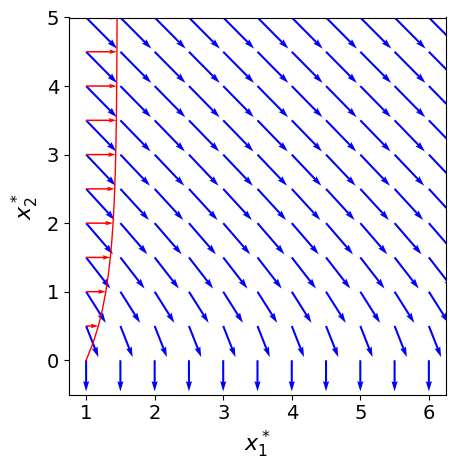

In [8]:
fig, ax = plt.subplots(tight_layout=True)
ax.set_xlabel('$x_1^*$')
ax.set_ylabel('$x_2^*$')
ax.set_ylim(-0.5,5)
ax.set_aspect('equal', 'box')

x1, x2 = np.meshgrid(np.linspace(1, 6, num=11),  # region of interest away from x_1=0
                     np.linspace(0, 5, num=11) )
ax.quiver(x1, x2, v1(x1,x2), v2(x1,x2), scale=2.2, scale_units='xy', color='blue')

# add v_2 example arrows and the envelope of v_2 magnitude,
# shift by 1 and mutiply by 1/2.2 because we scaled the arrows in the quiver by 2.2
x22 = np.linspace(0, 5, num=21)
ax.plot(1 + 1/2.2*v1(x1,x22), x22, color='red', linewidth='1')
x22 = x22[::2]
ax.quiver(np.ones_like(x22), x22, v1(1,x22), np.zeros_like(x22), scale=2.2,
          scale_units='xy', color='red', width=0.004);

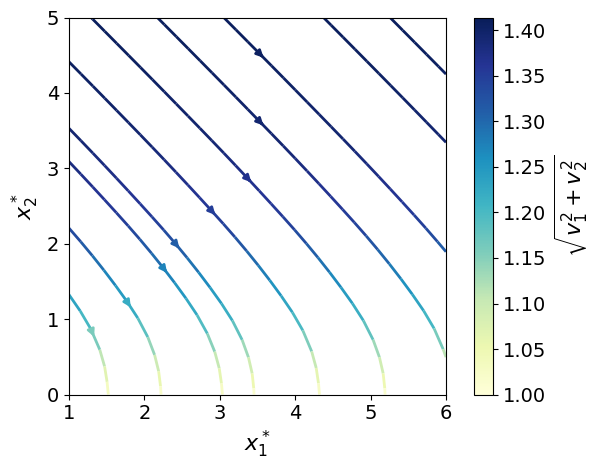

In [13]:
fig, ax = plt.subplots(tight_layout=True)
ax.set_xlabel('$x_1^*$')
ax.set_ylabel('$x_2^*$')
ax.set_ylim(0,5)
ax.set_aspect('equal', 'box')

x1, x2 = np.meshgrid(np.linspace(1, 6, num=14),  # region of interest away from x_1=0
                     np.linspace(0, 15, num=14) )

# customize the streamlines
starty = np.linspace(0.001, 15, num=35)
startx = np.ones_like(starty)
start = np.column_stack((startx,starty))

strm = ax.streamplot(x1, x2, v1(x1,x2), v2(x1,x2),
                     color=np.sqrt(v1(x1,x2)**2+v2(x1,x2)**2),
                     linewidth=2, cmap='YlGnBu', start_points=start)

plt.colorbar(strm.lines,label=r'$\sqrt{v_1^2+v_2^2}$');

## Another laminar "boundary layer thickness"

We can once again ask how far, $x_2=\delta$, above the porous plate at $x_1^*=0$ do we have to go before the horizontal velocity reaches $99\%$ of the incoming "free stream" velocity $U$.

This calculation is straightforward:
$$
v_2^*(x_{2}^* = \delta^*) = 1 - e^{-\delta^*} = 0.99
$$
or
$$
\delta^* = -\ln 0.01 \approx 4.6
$$
or
$$
\delta = (-\ln 0.01) \frac{\nu}{V} \approx 4.6 \frac{\nu}{V}.
$$
The thickness $\delta$ is independent of time and varies as $\nu$ (to the power 1), unlike Stokes' problems in which the boundary layer thickness went as $\nu^{1/2}$.

We can show it in a plot.

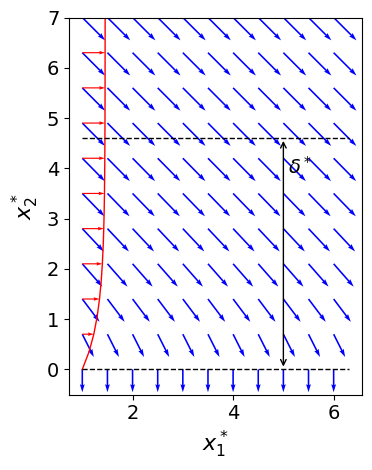

In [14]:
fig, ax = plt.subplots(tight_layout=True)
ax.set_xlabel('$x_1^*$')
ax.set_ylabel('$x_2^*$')
ax.set_ylim(-0.5,7)
ax.set_aspect('equal', 'box')

x1, x2 = np.meshgrid(np.linspace(1, 6, num=11),  # region of interest away from x_1=0
                     np.linspace(0, 7, num=11) )
ax.quiver(x1, x2, v1(x1,x2), v2(x1,x2), scale=2.2, scale_units='xy', color='blue')

# add v_2 example arrows and the envelope of v_2 magnitude,
# shift by 1 and mutiply by 1/2.2 because we scaled the arrows in the quiver by 2.2
x22 = np.linspace(0, 7, num=21)
ax.plot(1 + 1/2.2*v1(x1,x22), x22, color='red', linewidth='1')
x22 = x22[::2]
ax.quiver(np.ones_like(x22), x22, v1(1,x22), np.zeros_like(x22), scale=2.2,
          scale_units='xy', color='red', width=0.004);

x11 = np.linspace(1, 6.3, num=11)
ax.plot(x11, 4.6*np.ones_like(x11), color='black', linewidth=1, linestyle='dashed')
ax.plot(x11, 0*np.ones_like(x11), color='black', linewidth=1, linestyle='dashed')

# add nice arrows
ax.text(5.1, 3.9, r'$\delta^*$', fontdict={'size': 14})
ax.annotate("", (5, 0), (5, 4.6), arrowprops={'arrowstyle':'<->'});

## Further exploration

What does the vorticity field look like in this flow?